## Tarea 1
Programa Experto en Inteligencia Artificial con Python  
ML2006 - Visualización e Interpretación de Datos  
Estudiante: Natalia Bonilla Villalobos.  
**Introducción a la visualización de datos**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
<!-- - [Ejercicio 2](#ej2)
- [Ejercicio 3](#ej3) -->

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

<a id="ej1"></a>
# Ejercicio 1 
Para esta tarea se usará la base de datos **Football**, para ello descarge el archivo `Football.sqlite` del aula virtual y configure una conexión, por ejemplo  
`db <- dbConnect(SQLite(), dbname = ‘‘C:/Folder/Football.sqlite’’)`   
El conjunto de datos contiene resultados de partidos de fútbol para ligas europeas, así como datos sobre los jugadores y equipos para las temporas de 2008 a 2016. El archivo `Football diccionario.xlsx` contiene el detalle de columnas por tabla y su respectiva descripción.   

Para la conexión creada y con la ayuda de este diagrama, responda los siguientes puntos:   
  
![Evidencia Instalacion RStudio](diagrama_2.png)  
  

Realice los siguientes ejercicios utilizando matplotlib y/o seaborn.
- a) [15 puntos] Construya un dataframe que contenga tablas de posiciones por equipo para todas las ligas y temporadas (de primer lugar al último, esto es ordenada por puntos y diferencia de goles). Tomando como referencia la liga española para la temporada 2015/2016, muestre:
    - Ranking
    - Liga
    - Temporada
    - Nombre del equipo
    - Puntos total (3 puntos por gane, 1 por empate, 0 por pérdida)
    - Partidos jugados
    - Partidos empatados
    - Partidos perdidos
    - Goles a favor
    - Goles en contra
    - Diferencia de goles (a favor - en contra)

- b) [15 puntos] A partir del dataframe anterior,muestre un gráfico con los puntos por equipo para la Spain LIGA BBVA para la temporada 2014/2015. Ordene los resultados para una fácil interpretacion y agregue etiquetas para una rápida lectura.
- c) [20 puntos] Muestre ahora en un gráfico el total de puntos obtenidos para los mejores 5 equipos a lo largo de todas las temporadas en la Spain LIGA BBVA, esto es los 4 equipos
que han tenido más puntos en total durante todas esas temporadas, as´ı como el equipo que ganó la competición en cada temporada. Mostrar únicamente las etiquetas de los equipos
para la primera y última temporada e interprete los resultados.
- d) [20 puntos] Para la liga Spain LIGA BBVA, muestre un gráfico que compare la cantidad promedio de goles anotados como local y como visitante por temporada. Muestre ambas
métricas en la misma visualización, con etiquetas claras, e incluya una breve interpretación de los resultados observados.
- e) [10 puntos] Tomando el dataframe con todas las ligas y temporadas, muestre un gráfico con la Variabilidad de goles anotados promedio para todas las temporadas por Liga.
- f) [20 puntos] Ahora muestre en un gráfico el promedio de goles anotados como local y como visita durante todas las temporadas, por Liga. Muestre adicionalmente los promedios
generales para los goles de visita y local (todas ligas y temporadas). Ordene los resultados tomando como criterio los goles anotados como local.


[↑ Volver al Menú](#menu)


### Parte 1
- a) [15 puntos] Construya un dataframe que contenga tablas de posiciones por equipo para todas las ligas y temporadas (de primer lugar al último, esto es ordenada por puntos y diferencia de goles). Tomando como referencia la liga española para la temporada 2015/2016, muestre:
    - Ranking
    - Liga
    - Temporada
    - Nombre del equipo
    - Puntos total (3 puntos por gane, 1 por empate, 0 por pérdida)
    - Partidos jugados
    - Partidos empatados
    - Partidos perdidos
    - Goles a favor
    - Goles en contra
    - Diferencia de goles (a favor - en contra)

In [2]:
conn = sqlite3.connect('./../Football.sqlite')
df = pd.read_sql_query("""
select
    Liga, Temporada, Equipo, Equipo_longName,
    sum(Total_Puntos) as Total_Puntos,
    sum(Partidos_Jugados) as Partidos_Jugados,
    sum(Partidos_Empatados) as Partidos_Empatados,
    sum(Partidos_Perdidos) as Partidos_Perdidos,
    sum(GF) as GF,
    sum(GC) as GC,
    sum(GF) - sum(GC) as Diferencia_Goles
from(
    -- Local
    select l.name as Liga,
           m.season as Temporada,
           t.team_short_name as Equipo,
           t.team_long_name as Equipo_longName,
           case
               when m.home_team_goal > m.away_team_goal then 3
               when m.home_team_goal = m.away_team_goal then 1
               else 0
           end as Total_Puntos,
           1 as Partidos_Jugados,
           case when m.home_team_goal = m.away_team_goal then 1 else 0 end as Partidos_Empatados,
           case when m.home_team_goal < m.away_team_goal then 1 else 0 end as Partidos_Perdidos,
           m.home_team_goal as GF,
           m.away_team_goal as GC
    from Match m
    inner join (select distinct team_api_id, team_short_name, team_long_name from Team) t
        on m.home_team_api_id = t.team_api_id
    inner join League l
        on m.league_id = l.id

    UNION ALL

    -- Visitante
    select l.name as Liga,
           m.season as Temporada,
           t.team_short_name as Equipo,
           t.team_long_name as Equipo_longName,
           case
               when m.home_team_goal < m.away_team_goal then 3
               when m.home_team_goal = m.away_team_goal then 1
               else 0
           end as Total_Puntos,
           1 as Partidos_Jugados,
           case when m.home_team_goal = m.away_team_goal then 1 else 0 end as Partidos_Empatados,
           case when m.home_team_goal > m.away_team_goal then 1 else 0 end as Partidos_Perdidos,
           m.away_team_goal as GF,
           m.home_team_goal as GC
    from Match m
    inner join (select distinct team_api_id, team_short_name, team_long_name from Team) t
        on m.away_team_api_id = t.team_api_id
    inner join League l
        on m.league_id = l.id
) as tabla
group by
        Liga,
        Temporada,
        Equipo""", conn)
df
conn.close()

In [3]:
df

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45
1,Belgium Jupiler League,2008/2009,BAC,Beerschot AC,42,34,9,14,44,42,2
2,Belgium Jupiler League,2008/2009,CEB,KSV Cercle Brugge,47,34,5,15,48,53,-5
3,Belgium Jupiler League,2008/2009,CHA,Sporting Charleroi,43,34,7,15,43,48,-5
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9
...,...,...,...,...,...,...,...,...,...,...,...
1452,Switzerland Super League,2015/2016,SIO,FC Sion,50,36,8,14,52,49,3
1453,Switzerland Super League,2015/2016,THU,FC Thun,41,36,11,15,45,54,-9
1454,Switzerland Super League,2015/2016,VAD,FC Vaduz,36,36,15,14,44,60,-16
1455,Switzerland Super League,2015/2016,YB,BSC Young Boys,69,36,9,7,78,47,31


In [4]:
df = df.sort_values(
    by=[
        'Liga',
        'Temporada',
        'Total_Puntos',
        'Diferencia_Goles',
        'GF'
    ], ascending=[True, True, False, False, False]
)

In [5]:
df['Ranking'] = (
    df.groupby(['Liga', 'Temporada'])
      .cumcount() + 1
)

In [6]:
df

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Ranking
6,Belgium Jupiler League,2008/2009,GEN,KRC Genk,109,68,13,23,115,93,22,1
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45,2
13,Belgium Jupiler League,2008/2009,STL,Standard de Liège,77,34,5,5,66,26,40,3
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9,4
16,Belgium Jupiler League,2008/2009,ZUL,SV Zulte-Waregem,55,34,7,11,55,36,19,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1453,Switzerland Super League,2015/2016,THU,FC Thun,41,36,11,15,45,54,-9,6
1448,Switzerland Super League,2015/2016,GAL,FC St. Gallen,38,36,8,18,41,66,-25,7
1454,Switzerland Super League,2015/2016,VAD,FC Vaduz,36,36,15,14,44,60,-16,8
1450,Switzerland Super League,2015/2016,LUG,Lugano,35,36,8,19,46,75,-29,9


### Parte 2
- b) [15 puntos] A partir del dataframe anterior, muestre un gráfico con los puntos por equipo para la **Spain LIGA BBVA** para la **temporada 2014/2015**. Ordene los resultados para una fácil interpretacion y agregue etiquetas para una rápida lectura.

In [7]:
spainLigaBBVA = df[
    (df['Liga'] == 'Spain LIGA BBVA') &
    (df['Temporada'] == '2014/2015')
].reset_index(drop=True).sort_values(by=['Total_Puntos'], ascending=False)
spainLigaBBVA

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Ranking
0,Spain LIGA BBVA,2014/2015,BAR,FC Barcelona,94,38,4,4,110,21,89,1
1,Spain LIGA BBVA,2014/2015,REA,Real Madrid CF,92,38,2,6,118,38,80,2
2,Spain LIGA BBVA,2014/2015,AMA,Atlético Madrid,78,38,9,6,67,29,38,3
3,Spain LIGA BBVA,2014/2015,VAL,Valencia CF,77,38,11,5,70,32,38,4
4,Spain LIGA BBVA,2014/2015,SEV,Sevilla FC,76,38,7,8,71,45,26,5
5,Spain LIGA BBVA,2014/2015,VIL,Villarreal CF,60,38,12,10,48,37,11,6
6,Spain LIGA BBVA,2014/2015,BIL,Athletic Club de Bilbao,55,38,10,13,42,41,1,7
7,Spain LIGA BBVA,2014/2015,COR,RC Deportivo de La Coruña,55,76,25,41,57,128,-71,8
8,Spain LIGA BBVA,2014/2015,CEL,RC Celta de Vigo,51,38,12,13,47,44,3,9
9,Spain LIGA BBVA,2014/2015,MAL,Málaga CF,50,38,8,16,42,48,-6,10


In [84]:
# Diccionario de los nombres cortos con los nombres largos 
team_spainLigaBBVA = spainLigaBBVA.iloc[:, 2:4].copy()
dict_spainLigaBBVA = team_spainLigaBBVA.set_index('Equipo')['Equipo_longName'].to_dict()
dict_spainLigaBBVA['BAR']

'FC Barcelona'

In [90]:
# ??plt.bar

In [11]:
df_spain_14_15 = spainLigaBBVA.copy()
df_spain_14_15 = df_spain_14_15[
    [
        'Ranking',
        'Liga',
        'Temporada',
        'Equipo',
        'Total_Puntos',
        'Partidos_Jugados',
        'Partidos_Empatados',
        'Partidos_Perdidos',
        'GF',
        'GC',
        'Diferencia_Goles'
    ]
]
df_spain_14_15[:5]

,Ranking,Liga,Temporada,Equipo,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles
0,1,Spain LIGA BBVA,2014/2015,BAR,94,38,4,4,110,21,89
1,2,Spain LIGA BBVA,2014/2015,REA,92,38,2,6,118,38,80
2,3,Spain LIGA BBVA,2014/2015,AMA,78,38,9,6,67,29,38
3,4,Spain LIGA BBVA,2014/2015,VAL,77,38,11,5,70,32,38
4,5,Spain LIGA BBVA,2014/2015,SEV,76,38,7,8,71,45,26


In [127]:
def nombre_de_equipos(df_con_col_equipo):
    lista = []
    for equipo in df_con_col_equipo:
        lista.append(dict_spainLigaBBVA[equipo])
    return lista
        # print(f"{dict_spainLigaBBVA[equipo]}")
        
Equipos = nombre_de_equipos(df_spain_14_15['Equipo'])

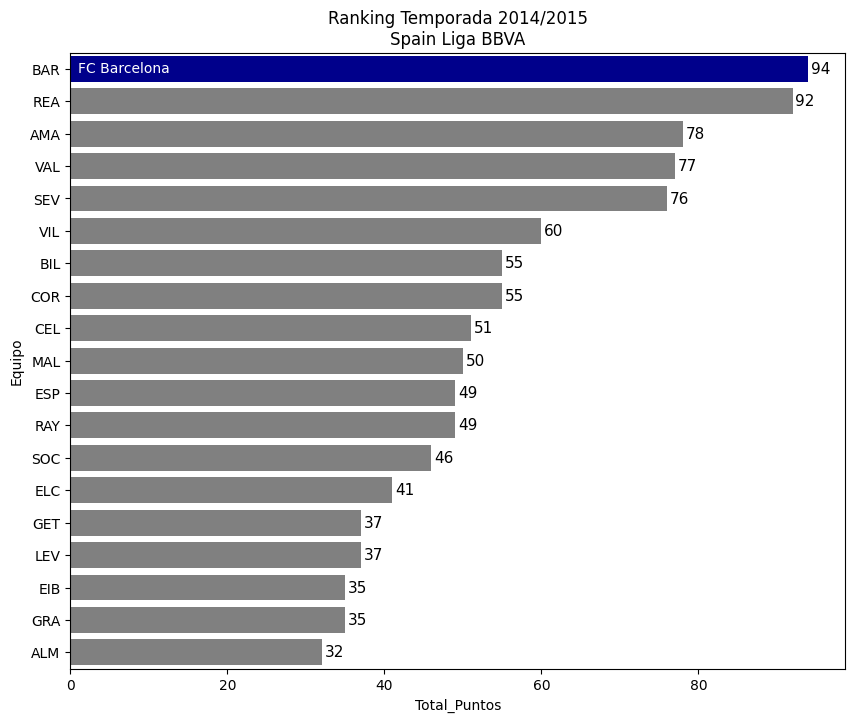

In [175]:
# df_spain_14_15['Equipo'] = df_spain_14_15['Equipo'].map(dic_equipos)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Total_Puntos', y='Equipo', data=df_spain_14_15, ax=ax, orient='h')

ax.set_title('Ranking Temporada 2014/2015\nSpain Liga BBVA')
ax.set

# etiquedas
ax.bar_label(ax.containers[0], padding=2, fontsize=11)
plt.xticks(rotation=0)

for patch in ax.patches:
    patch.set_facecolor('gray')

# solo la primera etiqueta cambia a azul    
ax.patches[0].set_facecolor('darkblue')


best_team = Equipos[0]
ax.annotate(best_team, 
            xytext = (1, 0.1), color='white', # weight="bold", # Texto y posición
            xy = (0.25, 0), # Punto inicial para la flecha
            xycoords = 'data', textcoords = 'data', # Utilizar los valores de los datos como las coordenadas
            # arrowprops = dict(arrowstyle = "->", connectionstyle = "arc3", color='white') # Dibujar una flecha
            )  


# texto_explicativo = f"Nota: Este gráfico muestra"
# plt.figtext(0.5, 0.01, texto_explicativo, ha="center", fontsize=8) #, 
#             #bbox={"facecolor": "white", "alpha": 0.1, "pad": 5})

plt.show()

### Parte 3
- c) [20 puntos] Muestre ahora en un gráfico el total de puntos obtenidos para los mejores 5 equipos a lo largo de todas las temporadas en la Spain LIGA BBVA, esto es los 4 equipos
que han tenido más puntos en total durante todas esas temporadas, así como el equipo que ganó la competición en cada temporada.  

    Mostrar únicamente las etiquetas de los equipos para la primera y última temporada e interprete los resultados.

In [176]:
df_SpainLiga_allSeasons = df[
    df['Liga'] == 'Spain LIGA BBVA'
]
df_SpainLiga_allSeasons.sample(5)

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Ranking
1269,Spain LIGA BBVA,2010/2011,GET,Getafe CF,44,38,8,18,49,60,-11,16
1298,Spain LIGA BBVA,2011/2012,VAL,Valencia CF,61,38,10,11,59,44,15,4
1270,Spain LIGA BBVA,2010/2011,HER,Hércules Club de Fútbol,35,38,8,21,36,60,-24,18
1367,Spain LIGA BBVA,2015/2016,LAS,UD Las Palmas,44,38,8,18,45,53,-8,12
1258,Spain LIGA BBVA,2009/2010,TEN,CD Tenerife,36,38,9,20,40,74,-34,17


In [198]:
campeones_spain = (
    df_SpainLiga_allSeasons.sort_values(
        by=['Temporada', 
            'Total_Puntos', 
            'Diferencia_Goles', 
            'GF'
            ], ascending=[True, False, False, False]
    ).groupby('Temporada').head(1)['Equipo'].unique() # la primera fila de c/g
)

In [199]:
for camp_spain in campeones_spain:
    print(dict_spainLigaBBVA[camp_spain], '<-', camp_spain)

Málaga CF <- MAL
Valencia CF <- VAL
FC Barcelona <- BAR
Atlético Madrid <- AMA


In [ ]:
top4 = (
    df_SpainLiga_allSeasons
    .groupby('Equipo')['Total_Puntos'].sum()
    .sort_values(ascending=False)
    .head(4)
)

In [ ]:
tp4_team = top4.to_frame().reset_index()
for top in tp4_team['Equipo']:
    print(dict_spainLigaBBVA[top], '<-', top)

FC Barcelona <- BAR
Real Madrid CF <- REA
Valencia CF <- VAL
Málaga CF <- MAL


In [213]:
# Top 5 es la suma de top4 historico + campeones que no estén ya
top5_equipos = list(top4.index)
for camp in campeones_spain:
    print(dict_spainLigaBBVA[camp], '<-' ,camp)
    if camp not in top5_equipos:
        print(f"{camp not in top5_equipos} {camp} is not top5")
        top5_equipos.append(camp)

# filtrar solo con los equipos
df_top5 = df_SpainLiga_allSeasons[
            df_SpainLiga_allSeasons['Equipo'].isin(top5_equipos)
        ].sort_values('Temporada')


Málaga CF <- MAL
Valencia CF <- VAL
FC Barcelona <- BAR
Atlético Madrid <- AMA
True AMA is not top5


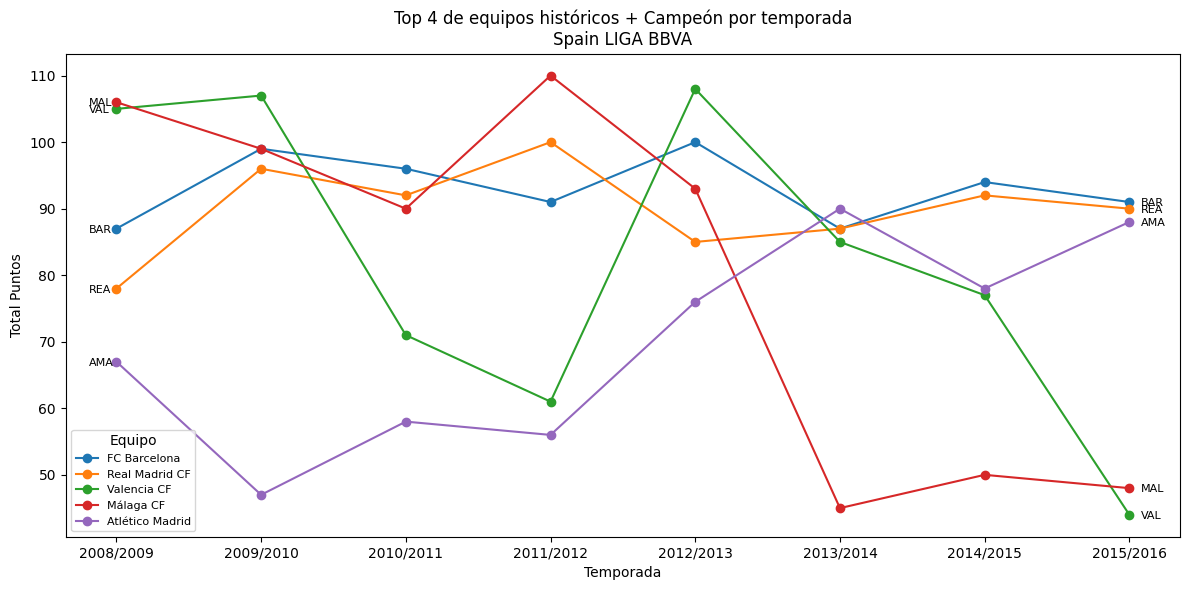

In [222]:
fig, ax = plt.subplots(figsize=(12, 6))

temporadas = sorted(df_top5['Temporada'].unique())
equipo_nombre_compl = []
for equipo in top5_equipos:
    data = df_top5[df_top5['Equipo'] == equipo].sort_values('Temporada')
    ax.plot(data['Temporada'], data['Total_Puntos'], marker='o', label=equipo)

    # etiquetas
    if not data.empty:
        season_1ra = data.iloc[0]
        ax.annotate(equipo, xy=(season_1ra['Temporada'], season_1ra['Total_Puntos']),
                    xytext=(-20, -3), textcoords='offset points', fontsize=8)
        season_ultima = data.iloc[-1]
        ax.annotate(equipo, xy=(season_ultima['Temporada'], season_ultima['Total_Puntos']),
                    xytext=(8, -3), textcoords='offset points', fontsize=8)
    
    equipo_nombre_compl.append(dict_spainLigaBBVA[equipo])

plt.legend(title='Equipo', loc='lower left', fontsize=8, title_fontsize=10, labels=equipo_nombre_compl)

ax.set_title('Top 4 de equipos históricos + Campeón por temporada\nSpain LIGA BBVA')
ax.set_xlabel('Temporada')
ax.set_ylabel('Total Puntos')
plt.tight_layout()
plt.show()

- FC Barcelona y Real Madrid CF:  
    Son los equipo más consistentes, se mantienen en casi todas las temporadas, alternándose el liderato, soon los equipos más fuertes del periodo.

- Málaga FC:  
    Empieza como uno de los mejores en la temporada 2008/2009, pero caé en la temporada 2013/2014 y no recupera.

- Valencia FC:  
    También arranca fuerte en la temporada 2009/2010 pero cae consistentemente hasta quedar en los últimos lugares al final de la temporada en 2015/2016.

- Atlético de Madrid:  
    Es el equipo que más creció, porque siendo el más débil en la temporada 2008/2009 termina siendo competitivo al nivel del FC Barcelona y del Real Madrid CF hacia la temporada 2015/2016.

### Parte 4
- d) [20 puntos] Para la liga Spain LIGA BBVA, muestre un gráfico que compare la cantidad promedio de goles anotados como local y como visitante por temporada. Muestre ambas métricas en la misma visualización, con etiquetas claras, e incluya una breve interpretación de los resultados observados.

In [223]:
conn = sqlite3.connect('./../Football.sqlite')
df_goles = pd.read_sql_query("""
select m.season as Temporada, 
    avg(m.home_team_goal) as Prom_Goles_Local,
    avg(m.away_team_goal) as Prom_Goles_Visita
    from Match m
    inner join League l
        on m.league_id = l.id
    where l.name = 'Spain LIGA BBVA'
    group by m.season
    order by m.season""", conn)
conn.close()

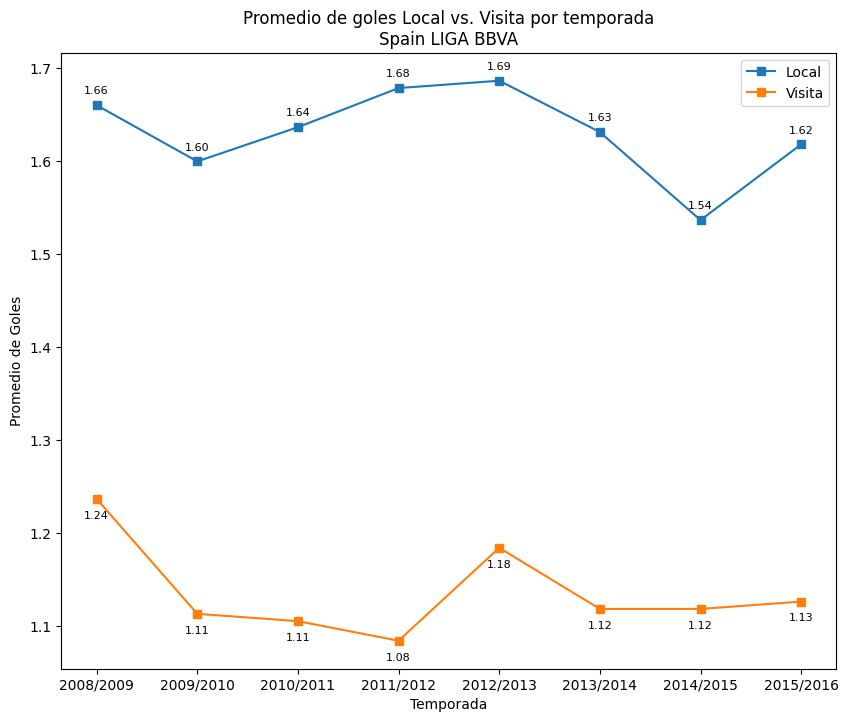

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df_goles['Temporada'], df_goles['Prom_Goles_Local'], marker='s', label='Local')
ax.plot(df_goles['Temporada'], df_goles['Prom_Goles_Visita'], marker='s', label='Visita')

# etiquetas para cada punto
for _, row in df_goles.iterrows():
    #anotaciones para el promedio de goles de local
    ax.annotate(f"{row['Prom_Goles_Local']:.2f}", 
                xy=(row['Temporada'], row['Prom_Goles_Local']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
    
    #anotaciones para el promedio de goles de visita
    ax.annotate(f"{row['Prom_Goles_Visita']:.2f}", 
                xy=(row['Temporada'], row['Prom_Goles_Visita']),
                xytext=(0, -14), textcoords='offset points', ha='center', fontsize=8)

ax.set_title('Promedio de goles Local vs. Visita por temporada\nSpain LIGA BBVA')
ax.set_xlabel('Temporada')
ax.set_ylabel('Promedio de Goles')
plt.legend()
plt.show()

En todas las temporadas(desde el 2008 al 2016) el promedio de goles como local supera al de visitante, o sea, que jugar en casa influye positivamente.  

Desde la temporada 2008/2009 han bajado la cantidad de goles, habiendo un pequeño aumento apartir de la temporada 2012/2013 pero apesar de esto, sigue estando por debajo de la temporada 2008/2009.  

Podriamos señalar las mejores y peores temporadas por promedio de goles vista y local:
- Local:
    - **Mejor** temporada por promedio de goles: 2012/2013 con un promerdio de 1.69 goles
    - **Peor** temporada por promedio de goles: 2014/2015 con un promerdio de 1.54 goles

- Visita:
    - **Mejor** temporada por promedio: 2008/2009 con un promerdio de 1.24 goles  
    - **Peor** temporada por promedio: 2011/2012 con un promerdio de 1.08 goles

### Parte 5
- e) [10 puntos] Tomando el dataframe con todas las ligas y temporadas, muestre un gráfico con la Variabilidad de goles anotados promedio para todas las temporadas por Liga.

In [232]:
conn = sqlite3.connect('./../Football.sqlite')
df_goles_ligas = pd.read_sql_query("""
    select 
        l.name as Liga,
        m.season as Temporada,
        avg(m.home_team_goal + m.away_team_goal) as Prom_Goles
    from Match m
    inner join League l on m.league_id = l.id
    group by l.name, m.season
    order by l.name, m.season
""", conn)
conn.close()

df_goles_ligas

,Liga,Temporada,Prom_Goles
0,Belgium Jupiler League,2008/2009,2.794118
1,Belgium Jupiler League,2009/2010,2.690476
2,Belgium Jupiler League,2010/2011,2.645833
3,Belgium Jupiler League,2011/2012,2.879167
4,Belgium Jupiler League,2012/2013,2.929167
...,...,...,...
83,Switzerland Super League,2011/2012,2.623457
84,Switzerland Super League,2012/2013,2.566667
85,Switzerland Super League,2013/2014,2.888889
86,Switzerland Super League,2014/2015,2.872222


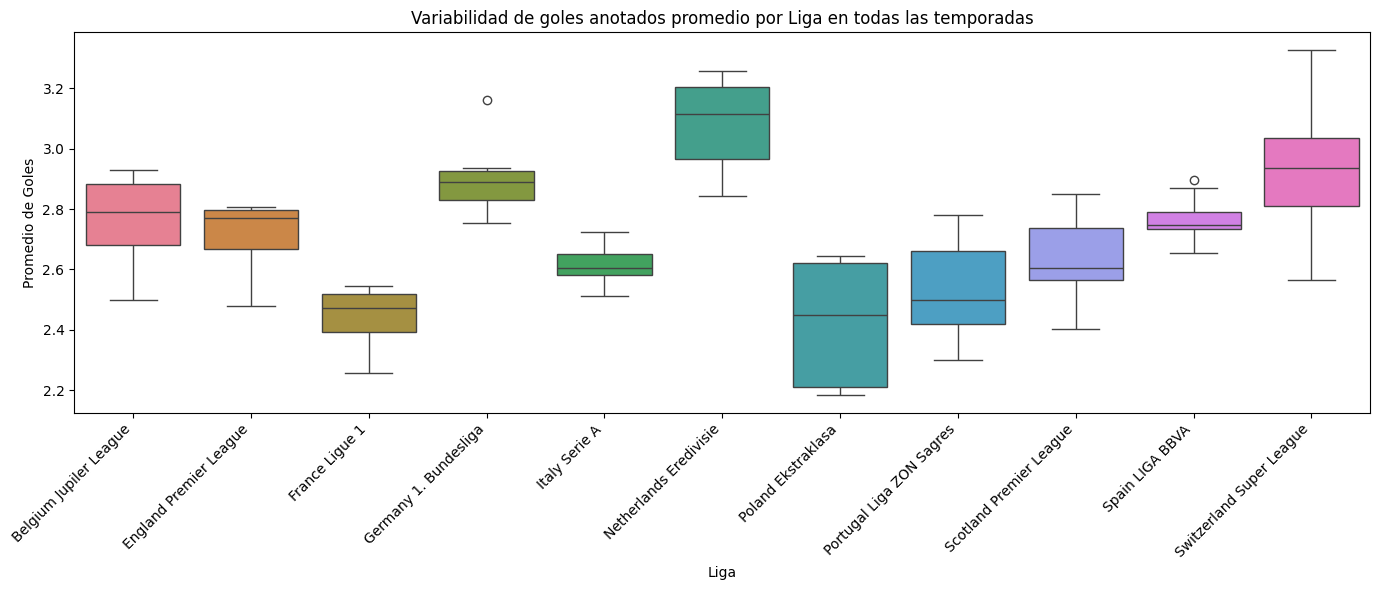

In [244]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_goles_ligas,
    x='Liga',
    y='Prom_Goles',
    ax=ax,
    hue='Liga'
)

ax.set_title('Variabilidad de goles anotados promedio por Liga en todas las temporadas')
ax.set_xlabel('Liga')
ax.set_ylabel('Promedio de Goles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Parte 6

- f) [20 puntos] Ahora muestre en un gráfico el promedio de goles anotados como local y como visita durante todas las temporadas, por Liga. Muestre adicionalmente los promedios
generales para los goles de visita y local (todas ligas y temporadas). Ordene los resultados tomando como criterio los goles anotados como local.

In [235]:
conn = sqlite3.connect('./../Football.sqlite')

df_goles_f = pd.read_sql_query("""
select 
    l.name as Liga,
    avg(m.home_team_goal) as Prom_Local,
    avg(m.away_team_goal) as Prom_Visita
from Match m
inner join League l
    on m.league_id = l.id
group by l.name
order by avg(m.home_team_goal) desc
""", conn)
conn.close()

# Promedios generales
promedio_general_local = df_goles_f['Prom_Local'].mean()
promedio_general_visitante = df_goles_f['Prom_Visita'].mean()

df_goles_f

,Liga,Prom_Local,Prom_Visita
0,Netherlands Eredivisie,1.779820,1.301062
1,Switzerland Super League,1.663150,1.266526
2,Spain LIGA BBVA,1.631250,1.135855
3,Germany 1. Bundesliga,1.626634,1.274918
4,Belgium Jupiler League,1.609375,1.192130
5,England Premier League,1.550987,1.159539
6,Italy Serie A,1.500829,1.116009
7,Scotland Premier League,1.429276,1.204496
8,Portugal Liga ZON Sagres,1.408382,1.126218
9,France Ligue 1,1.402961,1.040132


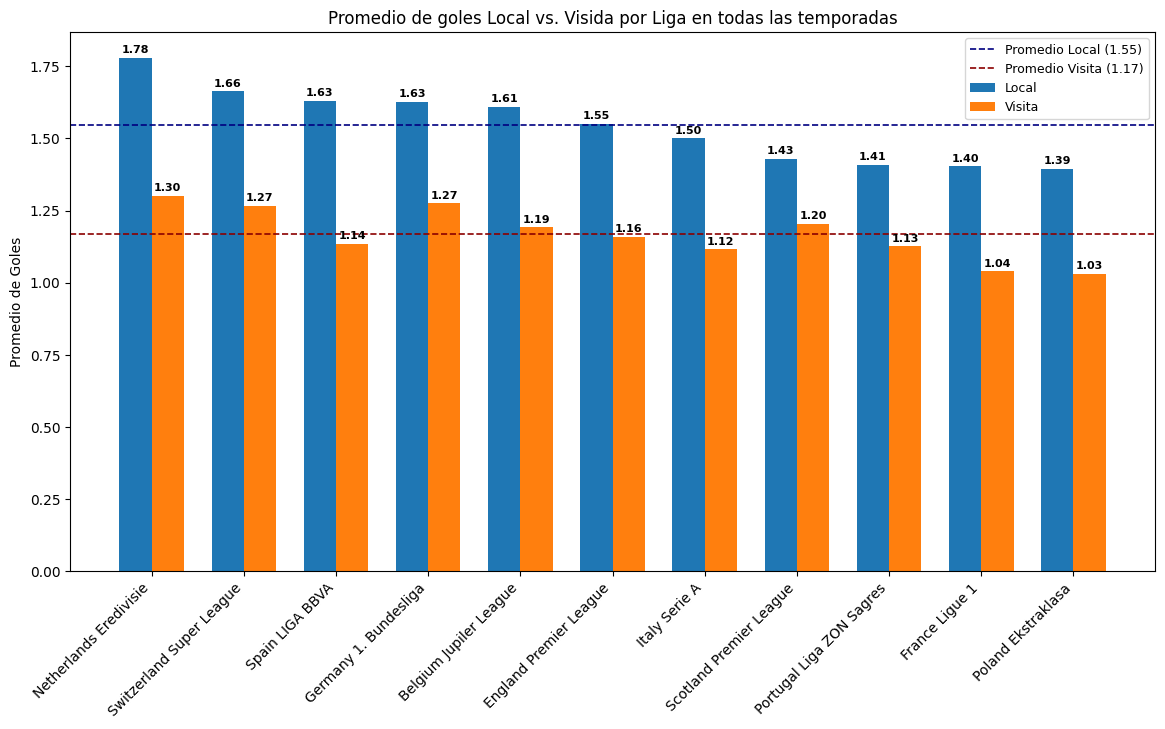

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(df_goles_f))
width = 0.35

bars_local = ax.bar([i - width/2 for i in x], df_goles_f['Prom_Local'], 
                     width=width, label='Local')
bars_visit = ax.bar([i + width/2 for i in x], df_goles_f['Prom_Visita'], 
                     width=width, label='Visita')

# lineas de promedio general
ax.axhline(promedio_general_local, color='navy', linestyle='--', 
           linewidth=1.2, label=f'Promedio Local ({promedio_general_local:.2f})')
ax.axhline(promedio_general_visitante, color='darkred', linestyle='--', 
           linewidth=1.2, label=f'Promedio Visita ({promedio_general_visitante:.2f})')

# etiquetas en las barras
ax.bar_label(bars_local, fmt='%.2f', padding=2, fontsize=8, weight ='bold')
ax.bar_label(bars_visit, fmt='%.2f', padding=2, fontsize=8, weight ='bold')

ax.set_title('Promedio de goles Local vs. Visida por Liga en todas las temporadas')

# ax.set_xlabel('Liga')
ax.set_ylabel('Promedio de Goles')
ax.set_xticks(list(x))
ax.set_xticklabels(df_goles_f['Liga'], rotation=45, ha='right')
plt.legend(fontsize=9)
# plt.tight_layout()
plt.show()

Se muestra nuevamente que el promedio de goles como Local es mayor al promedio de goles como visita.   

La liga 'Netherlands Eredivisie', tiene la mayor cantidad promedio de goles de Local como de Visita, con 1.78 y 1.30 respectivamente, además estan por arriba del promedio.  

Por el contrario, la liga 'Poland Ekstraklasa', es el que tiene menor cantdad promedio de goles de Local y Visita, 1.39 y 1.03 respectivamente y ambos por debajo del promedio.  
Le sigue muy de cerca la Liga 'France Ligue 1', con 1.40 y 1.04 promedio de goles para Local y Visita respectivamente, también por debajo del promedio.

Las ligas 'Netherlands Eredivisie', 'Switzerland Super League', 'Spain LIGA BBVA', 'Germany 1. Bundesliga' y 'Belgium Jupiler League' superan el promedio de goles como Local 1.55, línea azul punteada. Y en el puro limite del promedio tenemos la liga 'England Premier League'  .

Las ligas 'Spain LIGA BBVA', 'England Premier League', 'Italy Serie A', 'Portugal Liga ZON Sagres', 'France Ligue 1' y 'Poland Ekstraklasa' están por debajo de la línea roja punteada que tiene omo promedio de goles de Visita 1.17  
